# Laboratorio 5: Modelos en PyTorch
## Parte 3: Clasificación Multiclase (Dataset Multimodal - Audio)
Para esta última parte utilizaremos el dataset **FMA** (Free Music Archive), el cual cumple con la condición de ser un dataset multimodal (audio, aunque extraeremos sus características acústicas/metadatos), tener más de 100 propiedades ($n > 100$) y más de 5000 ejemplos ($m \ge 5000$).

El objetivo de esta red es clasificar a qué **género musical** pertenece una pista en base a sus propiedades acústicas (MFCC, contrastes espectrales, etc.).

In [1]:
# IMPORTANTE: Si estás ejecutando este cuadernillo en Google Colab,
# descomenta y ejecuta estas líneas para montar tu Google Drive.
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Mounted at /content/drive
Usando dispositivo: cuda


### 3.1 Carga del Dataset y Preprocesamiento
El dataset FMA puede tener diversas estructuras (archivos separados para metadata y características, múltiples filas de encabezado, etc.). Aquí asumiremos que hemos cargado un `.csv` plano o procesaremos el archivo de características.

In [2]:
# Ruta del Archivo CSV de música FMA Limpio (características y géneros)
archivo_fma = '/content/drive/MyDrive/LABSIS420/fma_limpio_balanceado.csv'

# Cargamos el archivo en Pandas. "low_memory=False" previene advertencias si hay columnas mixtas de datos.
df_fma = pd.read_csv(archivo_fma, low_memory=False)

# ---- Separar Características de Etiquetas ----
# X (Características de audio como tono, ritmo, espectro). Sacamos todas las columnas excepto la última (:-1)
X_pandas = df_fma.iloc[:, :-1].values
# Y (Géneros musicales en forma de TEXTO como "Rock", "Pop"). Extraemos únicamente la última columna (-1)
Y_pandas_raw = df_fma.iloc[:, -1].values

# --- Preprocesar Y (Codificación de Etiquetas Multiclase) ---
# El modelo no entiende la palabra "Rock" o "Pop", necesitamos convertirlo a números: Rock=0, Pop=1, etc.
# Usamos LabelEncoder de sklearn para hacer exactamente esto.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# fit_transform() escanea todas las palabras únicas y les asigna un número a cada una en un nuevo arreglo.
Y_pandas_encoded = le.fit_transform(Y_pandas_raw)

# m = número total de audios que tenemos en el dataset
m = len(Y_pandas_encoded)
# n = número total de columnas o "propiedades" que tiene cada audio
n = X_pandas.shape[1]
# np.unique cuenta cuántos géneros únicos (numeritos) se detectaron en total al codificar.
num_clases = len(np.unique(Y_pandas_encoded))

# Imprimimos los reportes de dimensiones para verificar que sea correcto
print(f"Total de ejemplos (m): {m} ")
print(f"Total de propiedades (n): {n} ")
# le.classes_ nos dice qué palabra pertenece al '0', cuál al '1', etc.
print(f"Clases identificadas: {num_clases} -> Corresponde a {le.classes_}")

Total de ejemplos (m): 14015 
Total de propiedades (n): 518 
Clases identificadas: 5 -> Corresponde a ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Rock']


### 3.2 División 80/20, Normalización y DataLoaders
Al tener muchas más propiedades (cientos) y datos en diferenes escalas (algunos en Hertz, otros con valores negativos como MFCCs), la estandarización ($z-score$) es **absolutamente crucial** para evitar el famoso *exploding gradient* o valores nulos (`NaN`).

In [3]:
# Calculamos el límite de dónde cortar para tener el 80% (Entrenamiento/Train) y 20% (Testeo)
limite_fma = int(0.8 * m)

# ¡MUY IMPORTANTE!: Mezclamos las filas aleatoriamente antes del split usando una permutacion aleatoria.
# Esto asegura que si los datos vienen ordenados ("Todos los Rock seguidos, luego todos los Pop") el modelo no colapse por sesgo.
indices = np.random.permutation(m)
X_pandas = X_pandas[indices]
Y_pandas_encoded = Y_pandas_encoded[indices]

# Recortamos las características X del 0% al 80% y del 80% al final
X_train_raw = X_pandas[:limite_fma]
X_test_raw = X_pandas[limite_fma:]
# Recortamos los géneros/respuestas Y del 0% al 80% y del 80% al final
Y_train = Y_pandas_encoded[:limite_fma]
Y_test = Y_pandas_encoded[limite_fma:]

# ---- Normalización Z-Score (Crucial en conjuntos grandes M y N) ----
# Calculamos Media de las columnas
X_mean = X_train_raw.mean(axis=0)
# Calculamos Desviación Estándar de las columnas (+ epsilon 1e-8 para no dividir entre 0)
X_std = X_train_raw.std(axis=0) + 1e-8

# Le aplicamos la estandarización a ambos conjuntos (train y test usan la misma regla de escala)
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

# ---- Transformación a Tensores Pytorch ----
# Para características, Pytorch quiere FloatTensor (números flotantes en 32 bits)
X_train_tensor = torch.from_numpy(X_train).float()
# ¡REGLA DE ORO DE PYTORCH MULTICLASE!: Para la función CrossEntropyLoss, 'Y' NO PUEDE ser un Float ni estar en forma de columna.
# Tiene que ser .long() (número entero grande de 64 bits) y en array de 1 sola dimensión plana (D, )
Y_train_tensor = torch.from_numpy(Y_train).long()

X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).long()

# ---- Creación del Dataset para PyTorch ----
class DatasetMulticlase(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Movemos las variables enteras a la Memoria Gráfica desde la inicialización
        self.X = X.to(device)
        self.Y = Y.to(device)
    def __len__(self):
        # Longitud de datos
        return len(self.X)
    def __getitem__(self, ix):
        # Retorna el Audio (X) y el Género Musical que es (Y)
        return self.X[ix], self.Y[ix]

# Preparamos las cajitas con los datos ya adaptados
dataset_train = DatasetMulticlase(X_train_tensor, Y_train_tensor)
dataset_test = DatasetMulticlase(X_test_tensor, Y_test_tensor)

# Lotes de a 500 audios procesados por vez
batch_size = 500

# DataLoaders: El de entrenamiento mezcla todo siempre por batch (shuffle=True), el de prueba no.
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

print("DataLoaders listos y verificados.")

DataLoaders listos y verificados.


### 3.3 Arquitectura de la Red Multiclase
Para la tarea muticlase, configuraremos una red neuronal profunda.

**Consideración Clave:**
En PyTorch, la función `nn.CrossEntropyLoss()` internamente aplica `LogSoftmax` y `NLLLoss`. Es decir, la salida de nuestro modelo debe ser de la forma $(Batch, Numero\_de\_Clases)$ y **no debemos aplicar manualmente la función `Softmax` al final de la capa**. Emitiremos los valores "crudos" o *logits*.

Iniciando Entrenamiento (Multiclase FMA)...
Epoch 30/150 - Costo: 0.00703 - Acierto Entrenamiento: 99.97%
Epoch 60/150 - Costo: 0.00209 - Acierto Entrenamiento: 99.94%
Epoch 90/150 - Costo: 0.00147 - Acierto Entrenamiento: 99.95%
Epoch 120/150 - Costo: 0.00072 - Acierto Entrenamiento: 99.96%
Epoch 150/150 - Costo: 0.00092 - Acierto Entrenamiento: 99.95%
Modelo guardado en: ./checkpoint_clasificacion_multiclase.pt


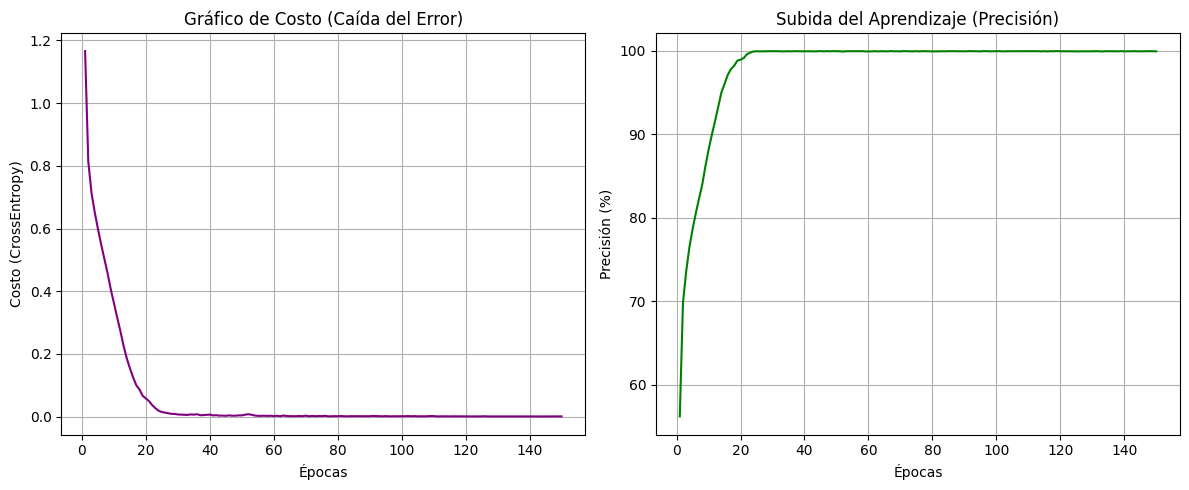

In [4]:
# --- 3.3 Arquitectura de la Red Multiclase ---
# D_in: Número total de características (features) extraídas del audio (>100)
D_in = n
# H1: Número de "neuronas" en la primera capa oculta. Usamos 250 porque hay mucha entrada de datos.
H1 = 250
# H2: Número de "neuronas" en la segunda capa oculta. Reducimos a 100 para extraer patrones clave.
H2 = 100
# D_out: Número de neuronas de salida. ¡Debe ser igual al número de géneros musicales! (ej: 16 géneros = 16 salidas)
D_out = num_clases

# Creamos el modelo con "Sequential" (una capa tras de otra en fila)
model_multi = nn.Sequential(
    # Capa Lineal 1 (Entrada de características -> Primera zona oculta)
    nn.Linear(D_in, H1),
    # Función ReLU: Convierte valores bajo cero a cero. Le da inteligencia "no lineal" a la red.
    nn.ReLU(),
    # Capa Lineal 2 (Comunica la primera zona oculta con la segunda)
    nn.Linear(H1, H2),
    # Función ReLU de nuevo
    nn.ReLU(),
    # Capa Lineal de Salida (Escupe "logits" o puntajes puros para cada género musical)
    # ¡OJO!: NO usamos Softmax aquí porque la función de pérdida que elegiremos más abajo ya la incluye internamente.
    nn.Linear(H2, D_out)
).to(device) # Movemos la red a la tarjeta gráfica si está disponible

# --- Función de Costo y Optimizador ---
# Usamos CrossEntropyLoss (Entropía Cruzada). Es el estándar mundial para "Adivinar la clase correcta entre muchas opciones".
criterion_multi = nn.CrossEntropyLoss()
# Usamos el optimizador Adam. Ajustará los pesos automáticamente de la red. lr=0.001 (velocidad de aprendizaje)
optimizer_multi = torch.optim.Adam(model_multi.parameters(), lr=0.001)

# Épocas: Cuántas veces procesará TODOS los datos.
epochs = 150
# Refresco en pantalla: Avisar cada 30 épocas
log_each = 30
# Lista para guardar y luego graficar la evolución del "error" (Costo)
l_multi = []
# Lista para guardar y luego graficar la evolución de los "aciertos" (Precisión / Accuracy)
acc_multi = []

# Pasamos explícitamente el modelo a modo "Entrenamiento"
model_multi.train()

print("Iniciando Entrenamiento (Multiclase FMA)...")
for e in range(1, epochs + 1): # Bucle que se repite 150 veces
    _l = [] # Variable vacía donde anotaremos los errores de "esta" época
    _acc = [] # Variable vacía donde anotaremos los % de acierto de "esta" época

    # Extraemos bloques de canciones (x_b) y sus etiquetas correctas (y_b)
    for x_b, y_b in dataloader_train:
        # PREDECIR: Le mostramos características de los audios al modelo y nos devuelve "predicciones"
        y_pred = model_multi(x_b)

        # JUZGAR (Loss): Comparamos lo que dijo el modelo (y_pred) vs el género real (y_b)
        loss = criterion_multi(y_pred, y_b)
        # Anotamos este número de error para la gráfica luego
        _l.append(loss.item())

        # EVALUAR ACIERTOS (%):
        # torch.max extrae la clase con más puntaje. La predicción real será ese número de clase
        _, prediccion = torch.max(y_pred, 1)
        # Comparamos si acertó exacto con y_b y promediamos.
        acuerdos = (prediccion == y_b).float().mean()
        # Lo multiplicamos x100 para tener un porcentaje claro y lo anotamos
        _acc.append(acuerdos.item() * 100)

        # BACKPROPAGATION Y APRENDIZAJE:
        # 1. Resetear cálculos matemáticos previos
        optimizer_multi.zero_grad()
        # 2. Calcular Derivadas (¿Qué parte del modelo cometió el error?)
        loss.backward()
        # 3. Mover los parámetros de la red un pasito para intentar no equivocarse en el siguiente intento
        optimizer_multi.step()

    # Terminó la época: Sacamos un promedio global de error y precisión del momento
    l_multi.append(np.mean(_l))
    acc_multi.append(np.mean(_acc))

    # Cada 30 vueltas informamos al programador el progreso en pantalla.
    if not e % log_each:
        print(f"Epoch {e}/{epochs} - Costo: {np.mean(_l):.5f} - Acierto Entrenamiento: {np.mean(_acc):.2f}%")

# Guardamos el archivo .pt que contiene toda la "experiencia" que ganó el modelo entrenando
PATH_MULTI = './checkpoint_clasificacion_multiclase.pt'
torch.save(model_multi.state_dict(), PATH_MULTI)
print(f"Modelo guardado en: {PATH_MULTI}")

# Dibujamos las dos gráficas de aprendizaje juntas
plt.figure(figsize=(12, 5))

# Gráfico 1: Cómo fue BAJANDO el error (Costo) con el pasar del tiempo. (Mientras más bajo, mejor)
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), l_multi, color='purple')
plt.title('Gráfico de Costo (Caída del Error)')
plt.xlabel('Épocas')
plt.ylabel('Costo (CrossEntropy)')
plt.grid(True)

# Gráfico 2: Cómo fue SUBIENDO el aprendizaje (Precisión). (Mientras más alto llegando a 100, mejor)
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), acc_multi, color='green')
plt.title('Subida del Aprendizaje (Precisión)')
plt.xlabel('Épocas')
plt.ylabel('Precisión (%)')
plt.grid(True)

# Hace que las dos gráficas no se choquen visualmente
plt.tight_layout()
plt.show()

### 3.4 Predicción y Precisión General del Modelo
Para predecir, tomamos el valor máximo del vector de logits resultante usando `torch.max()`. Este valor máximo indica la clase que la red neuronal cree que es más probable.

In [5]:
# 1. Poner Modo Evaluación: Desliga funciones que solo sirven a la hora de entrenar y que causarían ruido acá
model_multi.eval()

correctos = 0 # Contador que almacena aciertos totales
total = 0     # Contador de canciones analizadas

# 2. Desactivar cálculo de gradientes matemáticos: "Ya no aprenderé de mis errores hoy, me dedico a solo predecir"
with torch.no_grad():
    # Iteramos todos los datos que no se guardaron y sobraron para la revisión (Test de 20%)
    for x_b, y_b in dataloader_test:
        # Pasa los audios al modelo y sale una matriz con "Puntuaciones" para cada género.
        logits = model_multi(x_b)

        # torch.max Extrae el valor MAXIMO de cada array en una dimensión (=1).
        # Devuelve 2 cosas: (valor numérico alto, ID / índice que corresponde a ese número).
        # A nosotros nos interesa EL ID DE LA CLASE, porque nos dirá si es "0" o "4" etc. (prediccion_clase)
        _, prediccion_clase = torch.max(logits, 1)

        # Sumamos al total de canciones la cantidad escaneada en este batch actual (.size(0))
        total += y_b.size(0)

        # Comparamos si la prediccion de géneros (número) es IDENTICA al género real (numero).
        # Eso retorna True / False. Al sumarlos .sum().item() nos da cuántos True existieron en todo el lote
        correctos += (prediccion_clase == y_b).sum().item()

# Sacar porcentaje mundial: Exactitud (Accuracy)
accuracy = (correctos / total) * 100
print(f"La Precisión Multiclase (Accuracy general) alcanzada es: {accuracy:.2f}%\n")

# --- Bloque 3: Muestras Visuales uno por uno ----
# Tomamos arbitrariamente 15 ejemplos que guardamos como exclusividad
con_ejemplos = 15
X_prueba = X_test_tensor[:con_ejemplos].to(device)
Y_prueba = Y_test_tensor[:con_ejemplos].to(device)

with torch.no_grad(): # Nuevamente: cero aprendizaje = cero uso memoria gráfica inútil
    # Pedimos la predicción...
    logits_15 = model_multi(X_prueba)
    # Extraemos el índice del ganador
    _, predicciones_15 = torch.max(logits_15, 1)

print(f"--- Evaluando {con_ejemplos} Muestras Especiales ---")
for i in range(con_ejemplos):
    # .cpu() lo saca de la gpu. .item() lo convierte en un numerito llano.
    # inverse_transform de nuestra herramienta `le` REVIVE a los números volviendolos la "Palabra Real" ("Rock", "Pop")
    real = le.inverse_transform([Y_prueba[i].cpu().item()])[0]
    predicho = le.inverse_transform([predicciones_15[i].cpu().item()])[0]

    # Evaluar si la etiqueta con palabra es igual o distinta
    flag = "✅ Correcto" if real == predicho else "❌ Fallo"
    # Imprimimos de manera vistosa y ordenada con espacios:
    print(f"Fila {i+1} | Género Real: {real: <15} | Predicción: {predicho: <15} {flag}")

La Precisión Multiclase (Accuracy general) alcanzada es: 71.78%

--- Evaluando 15 Muestras Especiales ---
Fila 1 | Género Real: Experimental    | Predicción: Electronic      ❌ Fallo
Fila 2 | Género Real: Folk            | Predicción: Folk            ✅ Correcto
Fila 3 | Género Real: Experimental    | Predicción: Experimental    ✅ Correcto
Fila 4 | Género Real: Experimental    | Predicción: Rock            ❌ Fallo
Fila 5 | Género Real: Electronic      | Predicción: Experimental    ❌ Fallo
Fila 6 | Género Real: Hip-Hop         | Predicción: Hip-Hop         ✅ Correcto
Fila 7 | Género Real: Rock            | Predicción: Rock            ✅ Correcto
Fila 8 | Género Real: Experimental    | Predicción: Rock            ❌ Fallo
Fila 9 | Género Real: Experimental    | Predicción: Rock            ❌ Fallo
Fila 10 | Género Real: Experimental    | Predicción: Electronic      ❌ Fallo
Fila 11 | Género Real: Folk            | Predicción: Folk            ✅ Correcto
Fila 12 | Género Real: Electronic      | 

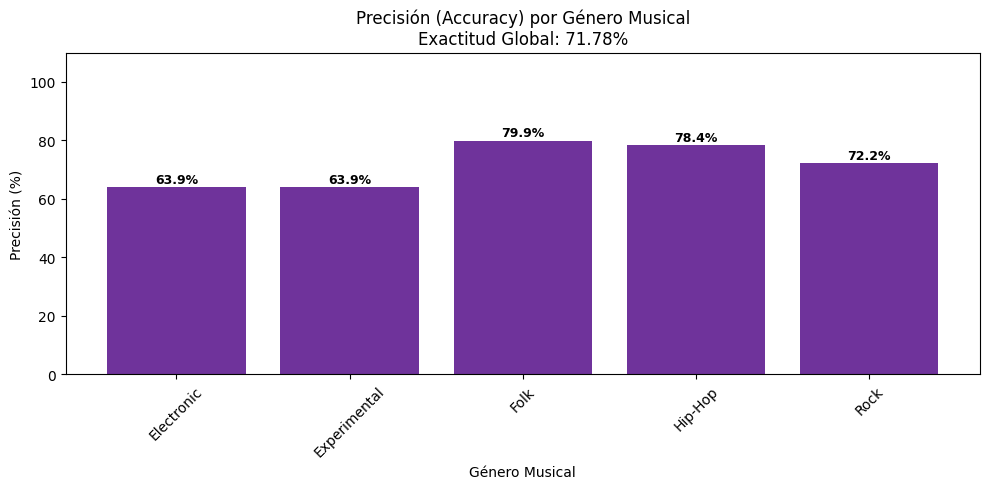

In [6]:
# --- 3.5 Gráfica de Precisión Multiclase ---
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

model_multi.eval()
y_true_all = []
y_pred_all = []

# Recolectar predicciones sobre todo el test set
with torch.no_grad():
    for x_b, y_b in dataloader_test:
        logits = model_multi(x_b)
        _, prediccion_clase = torch.max(logits, 1)

        y_true_all.extend(y_b.cpu().numpy())
        y_pred_all.extend(prediccion_clase.cpu().numpy())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Obtener los nombres reales de las etiquetas (Géneros Musicales)
labels_nombres = le.classes_

# Calcular matriz de confusión para sacar la precisión individual por clase
cm = confusion_matrix(y_true_all, y_pred_all)
precision_por_clase = cm.diagonal() / cm.sum(axis=1) * 100

# Gráfico de Barras Único (Precisión por Género)
plt.figure(figsize=(10, 5))
barras = plt.bar(labels_nombres, precision_por_clase, color='indigo', alpha=0.8)
plt.title(f'Precisión (Accuracy) por Género Musical\nExactitud Global: {accuracy:.2f}%')
plt.xlabel('Género Musical')
plt.ylabel('Precisión (%)')
plt.ylim(0, 110)
plt.xticks(rotation=45)

# Añadir porcentaje sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()